# Window Rotation Example

This notebook demonstrates how to use the random rotation augmentation when generating sliding windows.

In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import os
os.chdir(r"C:/Users/jamed/Documents/repos/terrain_classification_project/TerrainClassificationForFloodModelling")

In [6]:
from structured_data_utils.data import ModelData
import matplotlib.pyplot as plt
import torch

## Example 1: Generate windows WITHOUT rotation (original behavior)

In [7]:
# Standard usage without rotation
data_no_rotation = ModelData()
data_no_rotation.prepare_data("BEERMERY", sliding_window_size=300, stride=100, apply_rotation=False)
print(f"Shape without rotation: {data_no_rotation.segmented_data_with_labels.data.shape}")

pad_x: 338, pad_y: 265
282.0
starting
torch.Size([646, 300, 300])
tensor([0.4068, 0.4285, 0.4460, 0.4634, 0.4808, 0.4985, 0.5162, 0.5339, 0.5514,
        0.5688, 0.5862, 0.6037, 0.6211, 0.6385, 0.6559, 0.6736, 0.6913, 0.7090,
        0.7264, 0.7439, 0.7613, 0.7787, 0.7962, 0.8136, 0.8310, 0.8487, 0.8664,
        0.8841, 0.9015, 0.9189, 0.9364, 0.9538, 0.9713, 0.7215, 0.7301, 0.7619,
        0.7793, 0.7967, 0.8142, 0.8318, 0.8495, 0.8672, 0.8847, 0.9021, 0.9196,
        0.9370, 0.9544, 0.9718, 0.9870, 0.9964, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 0.7525, 0.9699, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 0.7702, 0.9525, 1.0000, 1.0000

## Example 2: Generate windows WITH random rotation

In [8]:
# Usage with rotation augmentation
# Each window will be randomly rotated by one of [0, 90, 180, 270] degrees
data_with_rotation = ModelData()
data_with_rotation.prepare_data("BEERMERY", sliding_window_size=300, stride=100, apply_rotation=True)
print(f"Shape with rotation: {data_with_rotation.segmented_data_with_labels.data.shape}")
print(f"Note: More windows due to random rotation augmentation!")

pad_x: 338, pad_y: 265
282.0
starting
torch.Size([1116, 300, 300])
tensor([0.4068, 0.4082, 0.4285,  ..., 0.7366, 0.7188, 0.7118])
torch.Size([1039, 300, 300])
Shape with rotation: torch.Size([3192, 300, 300])
Note: More windows due to random rotation augmentation!


## Example 3: Use custom rotation angles

In [9]:
# Use custom rotation angles instead of default [0, 90, 180, 270]
custom_angles = [0, 45, 90, 135, 180, 225, 270, 315]
data_custom_angles = ModelData()
data_custom_angles.prepare_data(
    "BEERMERY", 
    sliding_window_size=300, 
    stride=100, 
    apply_rotation=True,
    rotation_angles=custom_angles
)
print(f"Shape with custom angles: {data_custom_angles.segmented_data_with_labels.data.shape}")

pad_x: 338, pad_y: 265
282.0
starting
torch.Size([1219, 300, 300])
tensor([0.4068, 0.4082, 0.4285,  ..., 0.7366, 0.7188, 0.7120])
torch.Size([1143, 300, 300])
Shape with custom angles: torch.Size([3431, 300, 300])


## Example 4: Visualize rotated windows

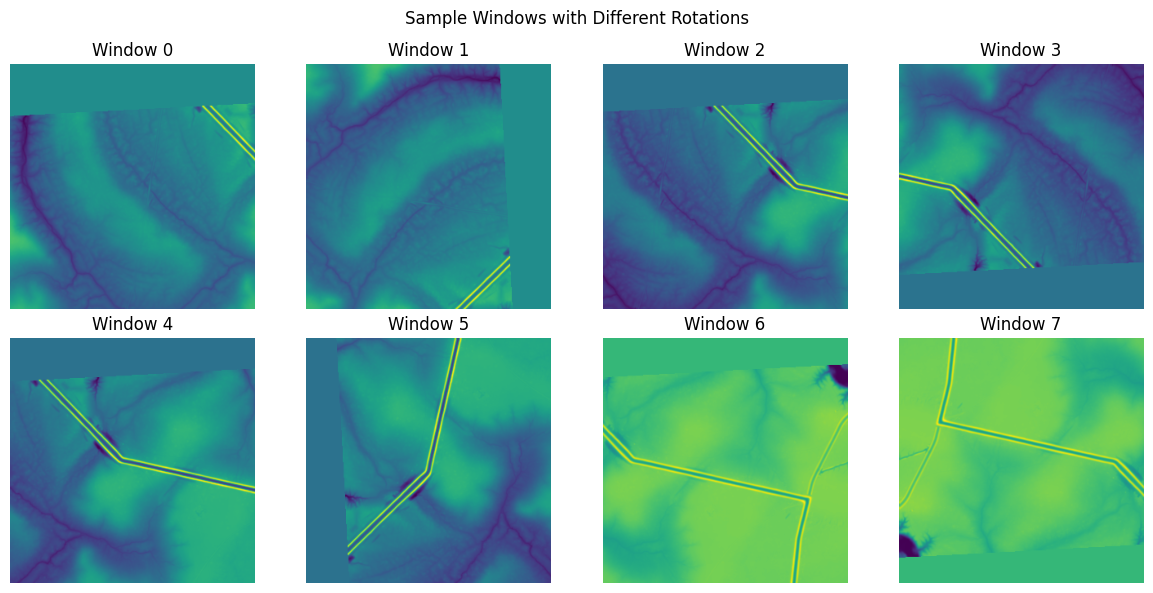

In [10]:
# Get a sample window and its rotated versions
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Windows with Different Rotations')

# Display windows 0, 1, 2, 3 (original + 3 rotated versions if rotation applied)
for idx in range(min(8, data_with_rotation.segmented_data_with_labels.data.shape[0])):
    ax = axes[idx // 4, idx % 4]
    window = data_with_rotation.segmented_data_with_labels.data[idx].numpy()
    ax.imshow(window, cmap='viridis')
    ax.set_title(f'Window {idx}')
    ax.axis('off')

plt.tight_layout()
plt.show()